# Import Libraries


In [62]:
import numpy as np
from scipy.stats import t
import matplotlib.pyplot as plt

# Import Helper Functions


In [63]:
import permutation_func as hf
import simdata as simd

# Simulate Data

the code below simulates 2D brain image data for two groups.Signal is then added to a small region in group 1. It outputs the data Y and the design matrix X.


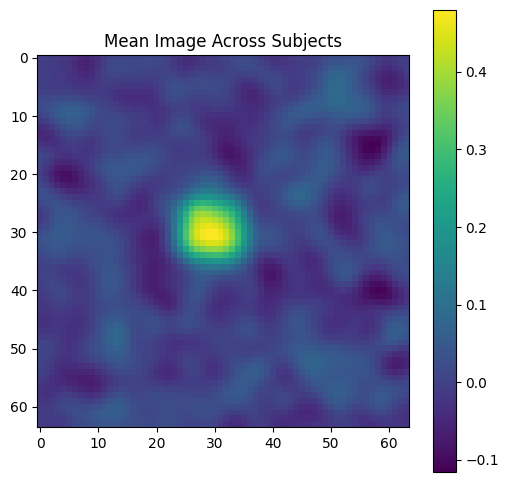

In [66]:
Y, design = simd.simulate_2d_data(
    n_subjects=20,
    shape=(64, 64),
    sigma=2,
    mode="group",
    signal_region=(slice(25, 35), slice(25, 35)),
    signal_strength=1,
    random_state=0
)

plt.imshow(Y.mean(axis=0))
plt.title("Mean Image Across Subjects")
plt.colorbar()
plt.show()


Above we can clearly see the reigon we have put the fake signal and we can see the random noise around it.

# Fit GLM

We fit the general linear model:

    Y = Xβ + ε

We then show one beta map.


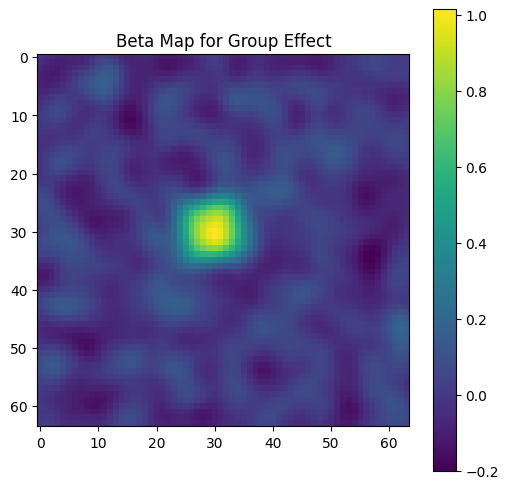

In [68]:
betas, resid = hf.fit_glm(design, Y)

plt.imshow(betas[1])
plt.title("Beta Map for Group Effect")
plt.colorbar()
plt.show()


# Compute T-Map

We create the t-map


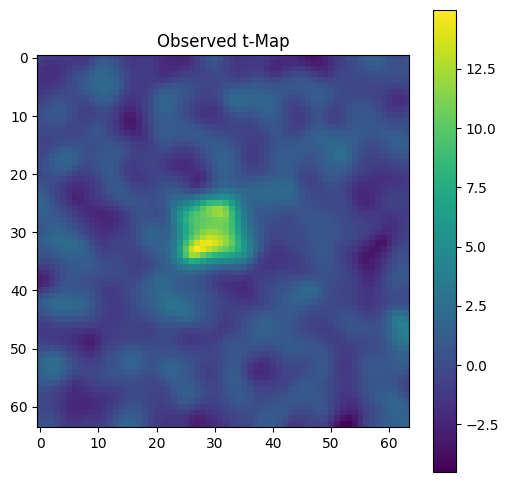

In [69]:
L = np.array([0, 1])  # contrast vector group effect
tmap = hf.tmap_from_L(design, betas, resid, L)

plt.imshow(tmap)
plt.title("Observed t-Map")
plt.colorbar()
plt.show()


# Compute t-Threshold

We compute the t-threshold for p=0.05.


In [57]:
df = design.shape[0] - design.shape[1]
t_threshold = t.ppf(1 - 0.05, df)
print("t-threshold =", t_threshold)


t-threshold = 1.7340636066175354


# Cluster Formation

We apply the threshold and display:
- binary threshold mask
- labeled clusters


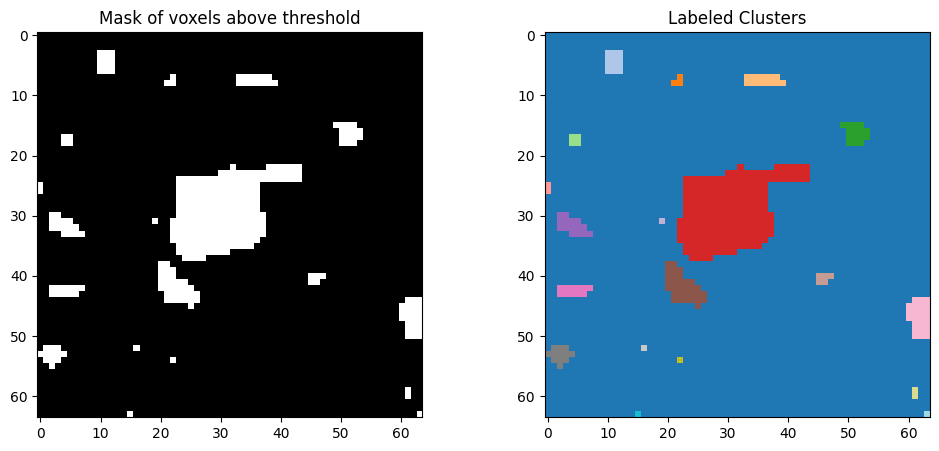

[np.float64(12.0),
 np.float64(3.0),
 np.float64(13.0),
 np.float64(15.0),
 np.float64(4.0),
 np.float64(216.0),
 np.float64(2.0),
 np.float64(15.0),
 np.float64(1.0),
 np.float64(32.0),
 np.float64(5.0),
 np.float64(11.0),
 np.float64(24.0),
 np.float64(12.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(1.0),
 np.float64(1.0)]

In [58]:
cluster_sizes, mask, labeled = hf.get_clusters_and_mask(tmap, t_threshold)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(mask, cmap="gray")
plt.title("Mask of voxels above threshold")

plt.subplot(1,2,2)
plt.imshow(labeled, cmap="tab20")
plt.title("Labeled Clusters")

plt.show()

cluster_sizes


# Permutation Cluster Test

We run the full permutation test and display:
- t-map
- cluster labels
- significant clusters


In [59]:
tmap_obs, labeled_obs, sig_clusters_mask, crit_cluster_size, max_cluster_sizes = hf.permutation_cluster_test(
    Y, design, L,
    threshold=t_threshold,
    n_permutations=300,
    alpha=0.05,
    random_state=0
)


# Visualization


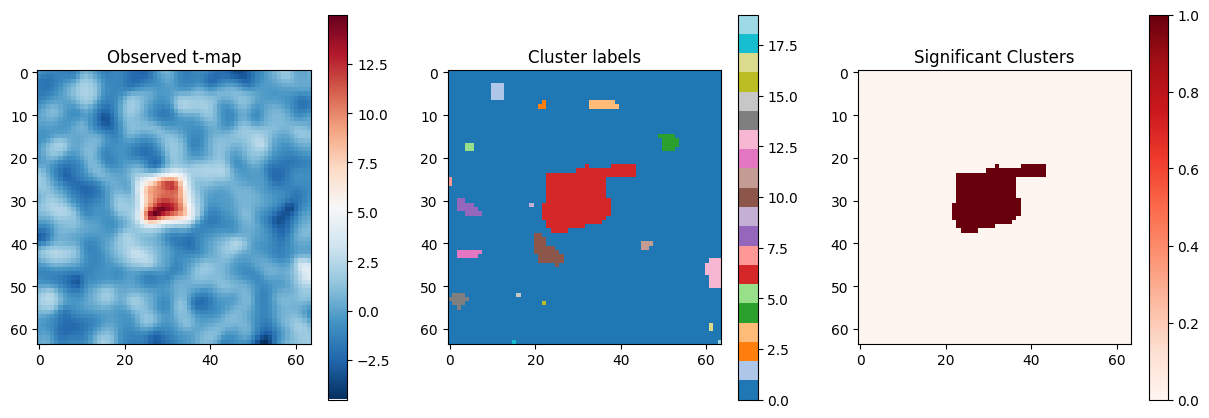

Critical cluster size = 97.0


In [60]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Observed t-map")
plt.imshow(tmap_obs, cmap='RdBu_r')
plt.colorbar()

plt.subplot(1,3,2)
plt.title("Cluster labels")
plt.imshow(labeled_obs, cmap='tab20')
plt.colorbar()

plt.subplot(1,3,3)
plt.title("Significant Clusters")
plt.imshow(sig_clusters_mask, cmap="Reds")
plt.colorbar()

plt.show()

print("Critical cluster size =", crit_cluster_size)


# Null Distribution of Max Cluster Sizes


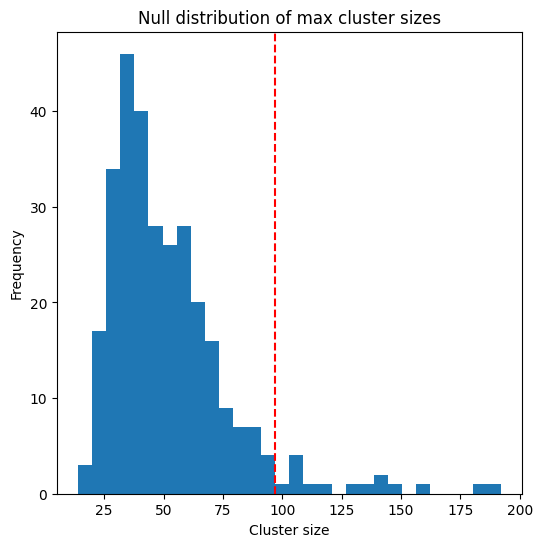

In [61]:
plt.hist(max_cluster_sizes, bins=30)
plt.axvline(crit_cluster_size, color='red', linestyle='--')
plt.title("Null distribution of max cluster sizes")
plt.xlabel("Cluster size")
plt.ylabel("Frequency")
plt.show()
